<a href="https://colab.research.google.com/github/lawesworks/vision-model-workbench/blob/main/vision_yolo_detector_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi -q
!nvidia-smi

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# CONFIGURATION
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# Roboflow Project Settings
#Roboflow_Project_URL = "https://universe.roboflow.com/karim-pxt0c/continuous_fire-smw6b"
#Roboflow_Project_URL = "https://universe.roboflow.com/objectdetection-6mzdy/license-plate-recognition-1qrok"
Roboflow_Project_URL = "https://universe.roboflow.com/roboflow-100/vehicles-q0x2v"
Roboflow_Dataset_Version = 1

# User Provided Sample / Test Image
CONFIG_SAMPLE_IMAGE = "https://cdn.bmwblog.com/wp-content/uploads/2020/06/BMW-4-Series-Coupe-license-plate-03.jpg"

# URL Regex
import re
Roboflow_URL_Regex_Pattern = r"roboflow\.com/([^/]+)/([^/?#]+)"
match = re.search(Roboflow_URL_Regex_Pattern, Roboflow_Project_URL)

#-------------------------------------------------------------------------------

# YOLO Model Config
YOLO_Model_Version = "yolov8"
YOLO_Model_Size = "n"

# Training Hyper-parameter Configs
Config_Epochs = 30
Config_Image_Size = 640
Config_Batch_Size = 16

#-------------------------------------------------------------------------------

Config_GPU_Batches_Per_Second = 3.5 # Iterations (Batches) per Second (As I Observed on Google TP4 GPU)

#-------------------------------------------------------------------------------
# Auto-Derived Parameters
if match:
    Roboflow_Project_Workspace = match.group(1)
    Roboflow_Project_Slug = match.group(2)
else:
    print("Roboflow URL format not recognized")
    Roboflow_Project_Workspace = ""
    Roboflow_Project_Slug = ""

Roboflow_Project_Name = ""
Roboflow_Project_Folder = ""
LATEST_PREDICT_DIR = "runs/detect/predict"
LATEST_TRAIN_DIR   = "runs/detect/train"

#-------------------------------------------------------------------------------

print(f"""
===== Training Configuration =====

Project URL      : {Roboflow_Project_URL}
Workspace        : {Roboflow_Project_Workspace}
Project Slug     : {Roboflow_Project_Slug}
Dataset Version  : {Roboflow_Dataset_Version}

Project Name     : {Roboflow_Project_Name}
Project Folder   : {Roboflow_Project_Folder}


Model            : {YOLO_Model_Version}
Model Size       : {YOLO_Model_Size}
Epochs           : {Config_Epochs}
Image Size       : {Config_Image_Size}
Batch Size       : {Config_Batch_Size}

==================================
""")


===== Training Configuration =====

Project URL      : https://universe.roboflow.com/roboflow-100/vehicles-q0x2v
Workspace        : roboflow-100
Project Slug     : vehicles-q0x2v
Dataset Version  : 1
      
Project Name     : 
Project Folder   : 


Model            : yolov8
Model Size       : n
Epochs           : 30
Image Size       : 640
Batch Size       : 16




In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Load Roboflow API Key
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

from google.colab import userdata
api_key = userdata.get('ROBOFLOW_API_KEY')

if api_key is None:
    raise ValueError("ROBOFLOW_API_KEY not found. Check Colab Secrets.")

print("Roboflow API Key Found")

Roboflow API Key Found


In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Load Libraries
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

from IPython.display import Image, display
import glob
import os

print(f"""
===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : display
glob
os

==================================
""")


===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : display
glob
os




In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Install Ultralytics
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

print("Installing Ultralytics (Please wait)\n")

!pip install -q roboflow ultralytics

print("\nCompleted Ultralytics Install")

Installing Ultralytics (Please wait)


Completed Ultralytics Install


In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Load Libraries
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

import math
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as DisplayImage, display
import torch
import glob
import os

print(f"""
===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : DisplayImage
matplotlib       : plt
torch
math
glob
os

==================================
""")


===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : DisplayImage
matplotlib       : plt
torch
math
glob
os




In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# HELPER FUNCTIONS
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++



# ----------------------------------------------------------------------------------------------------
# function to get GPU Summary
# ----------------------------------------------------------------------------------------------------
import torch

def get_gpu_cv_summary(device_index: int = 0) -> dict:
    """
    Return a concise GPU capability summary for CV / YOLO-style workloads.

    Returns a dict with:
      - property
      - value
      - why_it_matters
    """
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. Enable a GPU runtime or run on a CUDA-capable machine.")

    props = torch.cuda.get_device_properties(device_index)

    # Some attributes may not exist on all builds/versions; use getattr with fallback.
    summary = [
        {
            "property": "name",
            "value": props.name,
            "why_it_matters": "GPU generation & capabilities",
        },
        {
            "property": "total_memory",
            "value": f"{props.total_memory / (1024**3):.2f} GB",
            "why_it_matters": "Max batch size & image resolution",
        },
        {
            "property": "multi_processor_count",
            "value": props.multi_processor_count,
            "why_it_matters": "Parallel throughput",
        },
        {
            "property": "clock_rate",
            "value": f"{getattr(props, 'clock_rate', None) / 1000:.0f} MHz"
                     if getattr(props, "clock_rate", None) is not None else "N/A",
            "why_it_matters": "Kernel execution speed",
        },
        {
            "property": "memory_bus_width",
            "value": getattr(props, "memory_bus_width", "N/A"),
            "why_it_matters": "Data movement speed",
        },
        {
            "property": "warp_size",
            "value": props.warp_size,
            "why_it_matters": "Kernel efficiency",
        },
        {
            "property": "(major.minor)",
            "value": f"{props.major}.{props.minor}",
            "why_it_matters": "CUDA feature support / compute_capability ",
        },
    ]

    return {"device_index": device_index, "gpu_summary": summary}


# ----------------------------------------------------------------------------------------------------
# function to PRINT GPU Summary
# ----------------------------------------------------------------------------------------------------
def print_gpu_cv_summary(device_index: int = 0) -> None:
    """
    Pretty-print the GPU summary in a readable table-like format.
    """
    result = get_gpu_cv_summary(device_index)
    rows = result["gpu_summary"]

    print(f"\nGPU CV/YOLO Capability Summary (device {result['device_index']})")
    print("-" * 78)
    print(f"{'Property':<28} {'Value':<20} {'Why it matters'}")
    print("-" * 78)
    for r in rows:
        print(f"{r['property']:<28} {str(r['value']):<20} {r['why_it_matters']}")
    print("-" * 78)


# ----------------------------------------------------------------------------------------------------
# function to create image grid (Left → Right, Row Wrap) that will create a grid of Images saved to the Predicted Folder
# ----------------------------------------------------------------------------------------------------
def show_image_grid_paged(image_paths, cols=5, per_page=20, page=1, figsize_per_cell=3):
    """
    Display images in a true grid, paged.
    - cols: images per row
    - per_page: total images per page
    - page: 1-based page index
    - figsize_per_cell: size multiplier per grid cell
    """

    if not image_paths:
        print("No images to display.")
        return

    start = (page - 1) * per_page
    end = min(start + per_page, len(image_paths))
    page_paths = image_paths[start:end]

    rows = math.ceil(len(page_paths) / cols)
    fig_w = cols * figsize_per_cell
    fig_h = rows * figsize_per_cell

    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    axes = axes.flatten() if isinstance(axes, (list, tuple)) is False else axes

    # If only one subplot, axes may not be iterable the same way
    try:
        axes = axes.flatten()
    except Exception:
        axes = [axes]

    for ax in axes:
        ax.axis("off")

    for ax, img_path in zip(axes, page_paths):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Showing images {start+1}–{end} of {len(image_paths)} (page {page})")


# ----------------------------------------------------------------------------------------------------
# function to create image grid with titles. Flenames are truncates into titles for each image
# ----------------------------------------------------------------------------------------------------
def show_image_grid_with_short_titles(image_paths, cols=5, per_page=20, page=1, figsize_per_cell=3):
    #import math
    #import matplotlib.pyplot as plt
    #from PIL import Image

    start = (page - 1) * per_page
    end = min(start + per_page, len(image_paths))
    page_paths = image_paths[start:end]

    rows = math.ceil(len(page_paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*figsize_per_cell, rows*figsize_per_cell))
    try:
        axes = axes.flatten()
    except Exception:
        axes = [axes]

    for ax in axes:
        ax.axis("off")

    for ax, img_path in zip(axes, page_paths):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(img_path)[:18], fontsize=7)  # truncate title

    plt.tight_layout()
    plt.show()
    print(f"Showing images {start+1}–{end} of {len(image_paths)} (page {page})")


# ----------------------------------------------------------------------------------------------------
# function to determine estimated time of completion
# ----------------------------------------------------------------------------------------------------
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

def estimate_completion_time(minutes_from_now):
    now = datetime.now(ZoneInfo("America/New_York"))
    eta = now + timedelta(minutes=minutes_from_now)

    return {
        "start_time": now.strftime('%Y-%m-%d %H:%M:%S'),
        "estimated_completion": eta.strftime('%Y-%m-%d %H:%M:%S'),
        "minutes_from_now": minutes_from_now
    }




# ----------------------------------------------------------------------------------------------------
# function to estimate training time required for the model
# ----------------------------------------------------------------------------------------------------
def estimate_training_time(
    num_epochs,
    batch_size,
    train_image_count,
    val_image_count=0,
    batches_per_second=None,
    val_fraction_of_train_time=0.3
):
    """
    Estimate total training time.

    Provide either seconds_per_batch OR seconds_per_epoch (preferrably time for a full epoch).
    If both provided, seconds_per_epoch takes precedence.

    Returns dict with per-epoch and total estimates.
    """


    if batches_per_second is None:
        raise ValueError("Provide speed estimate in Iteractions (batch) per second.")

    seconds_per_batch = 1 / batches_per_second

    train_batches_per_epoch = math.ceil(train_image_count / batch_size)

    train_time_per_epoch = train_batches_per_epoch * seconds_per_batch
    val_time_per_epoch = 0
    if val_image_count > 0:
        # Option: scale validation time by image counts, or use fraction
        # Estimate validation time proportionally to image counts:
        val_batches_per_epoch = math.ceil(val_image_count / batch_size)
        val_time_per_epoch = val_batches_per_epoch * seconds_per_batch * val_fraction_of_train_time

    total_time_seconds = num_epochs * (train_time_per_epoch + val_time_per_epoch)

    return {
        "train_batches_per_epoch": train_batches_per_epoch,
        "train_time_per_epoch_sec": round(train_time_per_epoch, 2),
        "val_time_per_epoch_sec": round(val_time_per_epoch, 2),
        "total_time_sec": round(total_time_seconds, 2),
        "total_time_min": round(total_time_seconds / 60, 2),
        "total_time_hr": round(total_time_seconds / 3600, 2),
        "seconds_per_batch": round(seconds_per_batch, 4),
    }



# ----------------------------------------------------------------------------------------------------
# function to count images in given folder
# ----------------------------------------------------------------------------------------------------
def count_images(folder):
    extensions = ("*.jpg", "*.jpeg", "*.png")
    count = 0
    for ext in extensions:
        count += len(glob.glob(os.path.join(folder, ext)))
    return count


# ----------------------------------------------------------------------------------------------------
# function to get latest training path DIR
# ----------------------------------------------------------------------------------------------------
def get_latest_training_path():
    training_dirs = sorted(
        glob.glob("/content/runs/detect/train*"),
        key=os.path.getmtime
    )

    if not training_dirs:
        raise FileNotFoundError("No YOLO training runs found in runs/detect/")

    train_dir = training_dirs[-1]
    print(f"\nUsing training run from: {train_dir}")
    return train_dir



# ----------------------------------------------------------------------------------------------------
# function to get latest prediction path DIR
# ----------------------------------------------------------------------------------------------------
def get_latest_prediction_path():
  predict_dirs = sorted(
    glob.glob("runs/detect/predict*"),
    key=os.path.getmtime
  )

  PREDICT_DIR = predict_dirs[-1]
  print(f"\n\nUsing predictions from: {PREDICT_DIR}")
  return PREDICT_DIR


# ----------------------------------------------------------------------------------------------------
# function to get latest model best.pt path
# ----------------------------------------------------------------------------------------------------
def get_latest_pt_path(latest_train_path):
  pt_files = glob.glob(f"{latest_train_path}/weights/best.pt", recursive=True)

  if not pt_files:
      raise FileNotFoundError("No best.pt file found")

  return pt_files[0]

# ----------------------------------------------------------------------------------------------------
# function to get list of predicted / inferenced images
# ----------------------------------------------------------------------------------------------------
def get_inferenced_images(predict_dir):
  image_paths = glob.glob(os.path.join(predict_dir, "*.jpg")) + \
              glob.glob(os.path.join(predict_dir, "*.png"))

  return sorted(image_paths)


print(f"""
===== Loaded Helper Functions =====

show_image_grid_paged              :
show_image_grid_with_short_titles  :
estimate_completion_time           :
estimate_training_time             :
count_images                       :
get_latest_training_path           :
get_latest_prediction_path         :
get_latest_pt_path                 :
get_inferenced_images              :

==================================
""")


===== Loaded Helper Functions =====

show_image_grid_paged              :
show_image_grid_with_short_titles  :
estimate_completion_time           :
estimate_training_time             :
count_images                       :
get_latest_training_path           :
get_latest_prediction_path         :
get_latest_pt_path                 :
get_inferenced_images              :




In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Import the Dataset that will be used to train your model
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

print(f"Importing Dataset: [{Roboflow_Project_Slug}, Version: [{Roboflow_Dataset_Version}] from: [{Roboflow_Project_Workspace}] (Please wait)\n")

from roboflow import Roboflow


rf = Roboflow(api_key=api_key )
project = rf.workspace(Roboflow_Project_Workspace).project(Roboflow_Project_Slug)

dataset = project.version(Roboflow_Dataset_Version).download(YOLO_Model_Version)  # adjust version if needed

# Store Official Project Name and Folder location to Local Variables
Roboflow_Project_Name = project.name
Roboflow_Project_Folder = dataset.location

print(f"\nCompleted Dataset Import: {Roboflow_Project_Name}")

# Get Image Count within Training and Validation folders
Data_Train_Count = count_images(os.path.join(Roboflow_Project_Folder, "train", "images"))
Data_Valid_Count = count_images(os.path.join(Roboflow_Project_Folder, "valid", "images"))


print(f"""
===== Training Data Statistics =====

Roboflow Project Name              : {Roboflow_Project_Name}
Roboflow Project Folder            : {Roboflow_Project_Folder}
Training Image Count               : {Data_Train_Count}
Validation Image Count             : {Data_Valid_Count}

====================================
""")

Importing Dataset: [vehicles-q0x2v, Version: [1] from: [roboflow-100] (Please wait)

loading Roboflow workspace...
loading Roboflow project...

Completed Dataset Import: vehicles

===== Training Data Statistics =====

Roboflow Project Name              : vehicles
Roboflow Project Folder            : /content/vehicles-1
Training Image Count               : 2634
Validation Image Count             : 966




In [ ]:

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# get location of the yaml file for this project
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

yaml_files = glob.glob(f"{Roboflow_Project_Folder}/data.yaml", recursive=True)

if not yaml_files:
    raise FileNotFoundError("No data.yaml file found")

DATA_YAML_PATH = yaml_files[0]

print(f"Using dataset config: {DATA_YAML_PATH}")

Using dataset config: /content/vehicles-1/data.yaml


In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Estimate Time Required to Complete Training
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

estimate = estimate_training_time(
    num_epochs=Config_Epochs,
    batch_size=Config_Batch_Size,
    train_image_count = Data_Train_Count,
    val_image_count = Data_Valid_Count,
    batches_per_second = Config_GPU_Batches_Per_Second,
    val_fraction_of_train_time=0.3
)


# print time estimates
for k, v in estimate.items():
    print(f"{k:<30}: {v}")

# print estimate time of completion
eta_info = estimate_completion_time(estimate["total_time_min"])
for k, v in eta_info.items():
  print(f"{k:<30}: {v}")

print("\n")
print_gpu_cv_summary(0)


train_batches_per_epoch       : 165
train_time_per_epoch_sec      : 47.14
val_time_per_epoch_sec        : 5.23
total_time_sec                : 1571.14
total_time_min                : 26.19
total_time_hr                 : 0.44
seconds_per_batch             : 0.2857
start_time                    : 2026-02-13 00:18:29
estimated_completion          : 2026-02-13 00:44:41
minutes_from_now              : 26.19



GPU CV/YOLO Capability Summary (device 0)
------------------------------------------------------------------------------
Property                     Value                Why it matters
------------------------------------------------------------------------------
name                         Tesla T4             GPU generation & capabilities
total_memory                 14.56 GB             Max batch size & image resolution
multi_processor_count        40                   Parallel throughput
clock_rate                   N/A                  Kernel execution speed
memory_bus_width  

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# train  model on the data
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


print("Training The Model (Please wait)\n")
print(f"""
===== Training Hyper-parameters =====

Model            : {YOLO_Model_Version}
Model Size       : {YOLO_Model_Size}
Epochs           : {Config_Epochs}
Image Size       : {Config_Image_Size}
Batch Size       : {Config_Batch_Size}
Train Count      : {Data_Train_Count}
Valid Count      : {Data_Valid_Count}

=====================================
""")


from ultralytics import YOLO

DATA_YAML_PATH = DATA_YAML_PATH

model = YOLO("yolov8n.pt")  # small + fast starter model
results = model.train(
    data=DATA_YAML_PATH,
    epochs=Config_Epochs,
    imgsz=Config_Image_Size,
    batch=Config_Batch_Size
)

# get latest training folder - save it to variabble
LATEST_TRAIN_DIR = get_latest_training_path()


In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# get location of the weights for the latest training
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


MODEL_PT_PATH = get_latest_pt_path(LATEST_TRAIN_DIR)

print(f"Using PT File: {MODEL_PT_PATH}")

Using PT File: /content/runs/detect/train/weights/best.pt


In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# run the model against the test data in your project
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

best_model_path = glob.glob(MODEL_PT_PATH)[-1]
model = YOLO(best_model_path)

model.predict(source = Roboflow_Project_Folder + "/test/images", save=True, conf=0.25)

LATEST_PREDICT_DIR = get_latest_prediction_path()

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Get list of latest predicted / inferenced images
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


image_paths = get_inferenced_images(LATEST_PREDICT_DIR)

print(f"Found {len(image_paths)} predicted images")

Found 458 predicted images


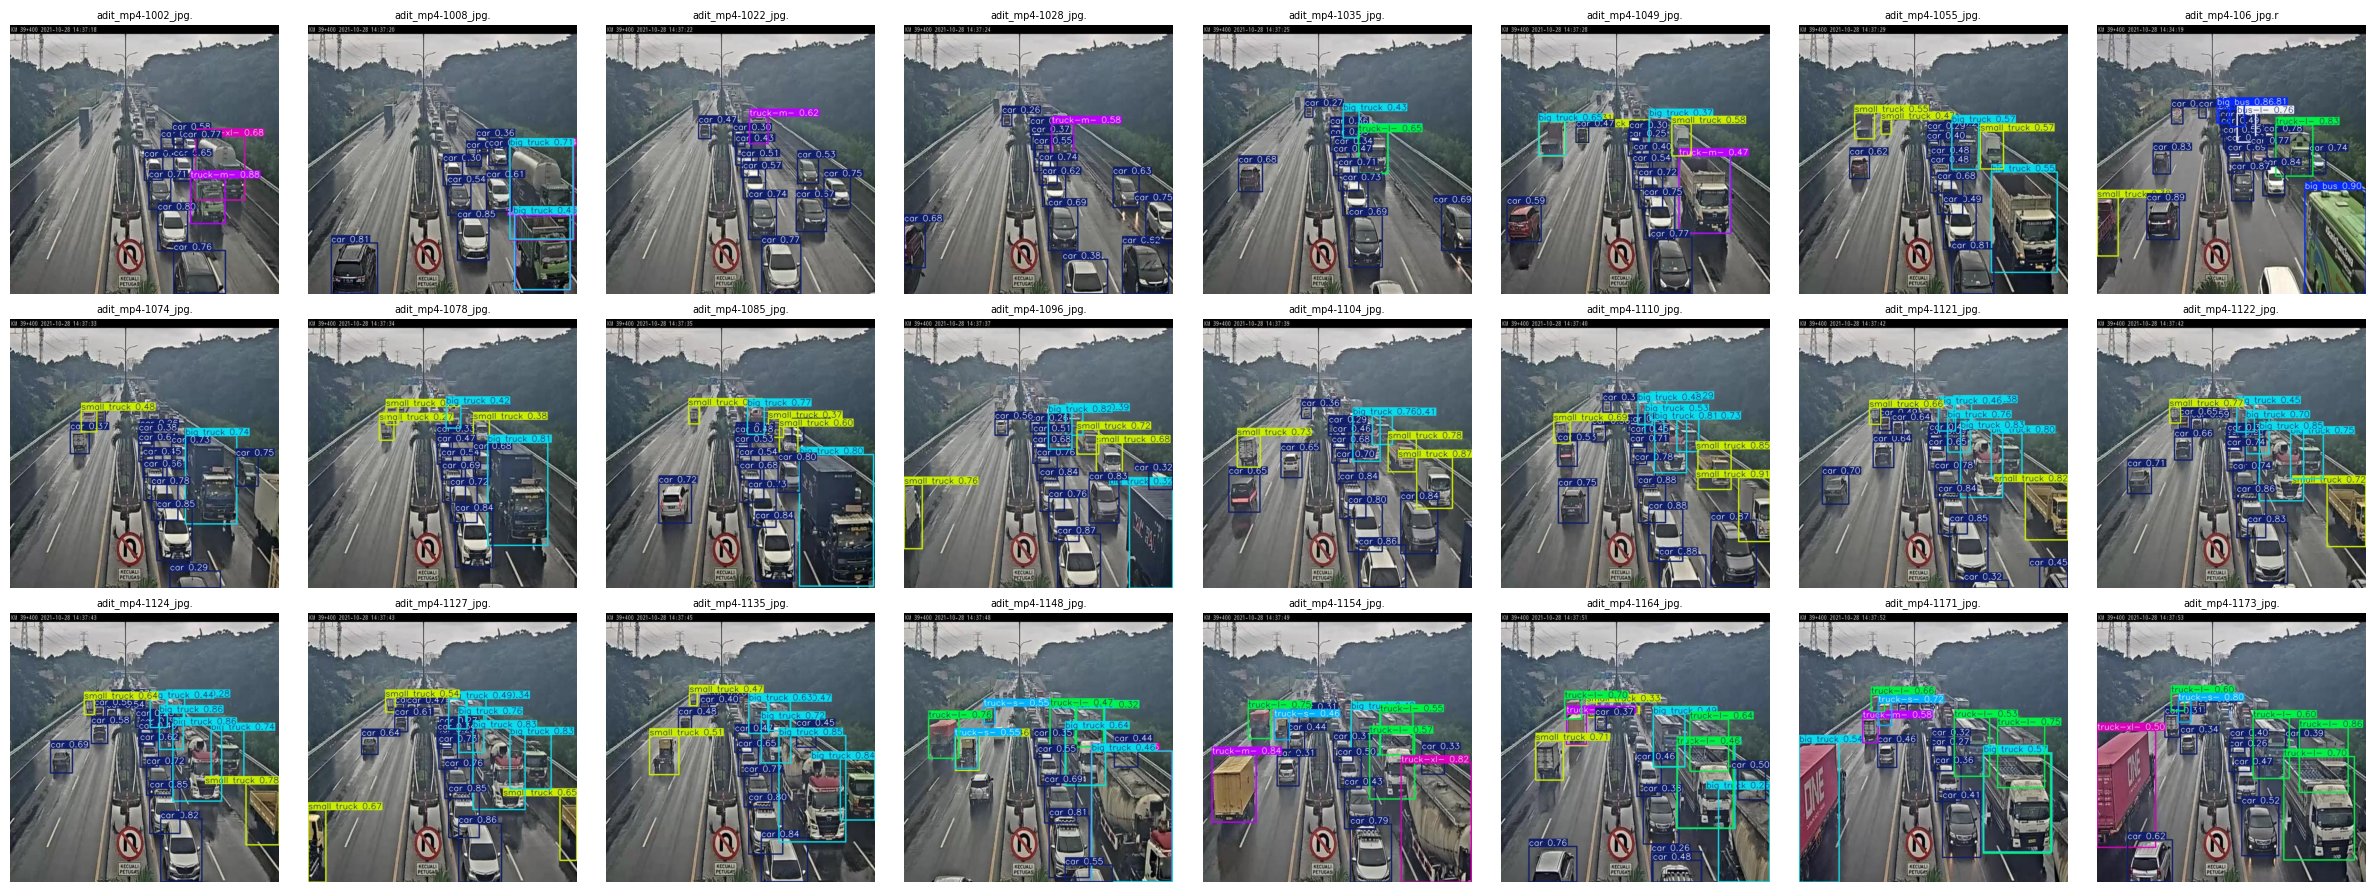

Showing images 1–24 of 458 (page 1)


In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Show images in the Recent Predictions Folder
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


# show first 20 images, 5 per row
# show_image_grid_paged(image_paths, cols=8, per_page=24, page=1)

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Show first 20 images with titles, 5 per row
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

show_image_grid_with_short_titles(image_paths, cols=8, per_page=24, page=1)


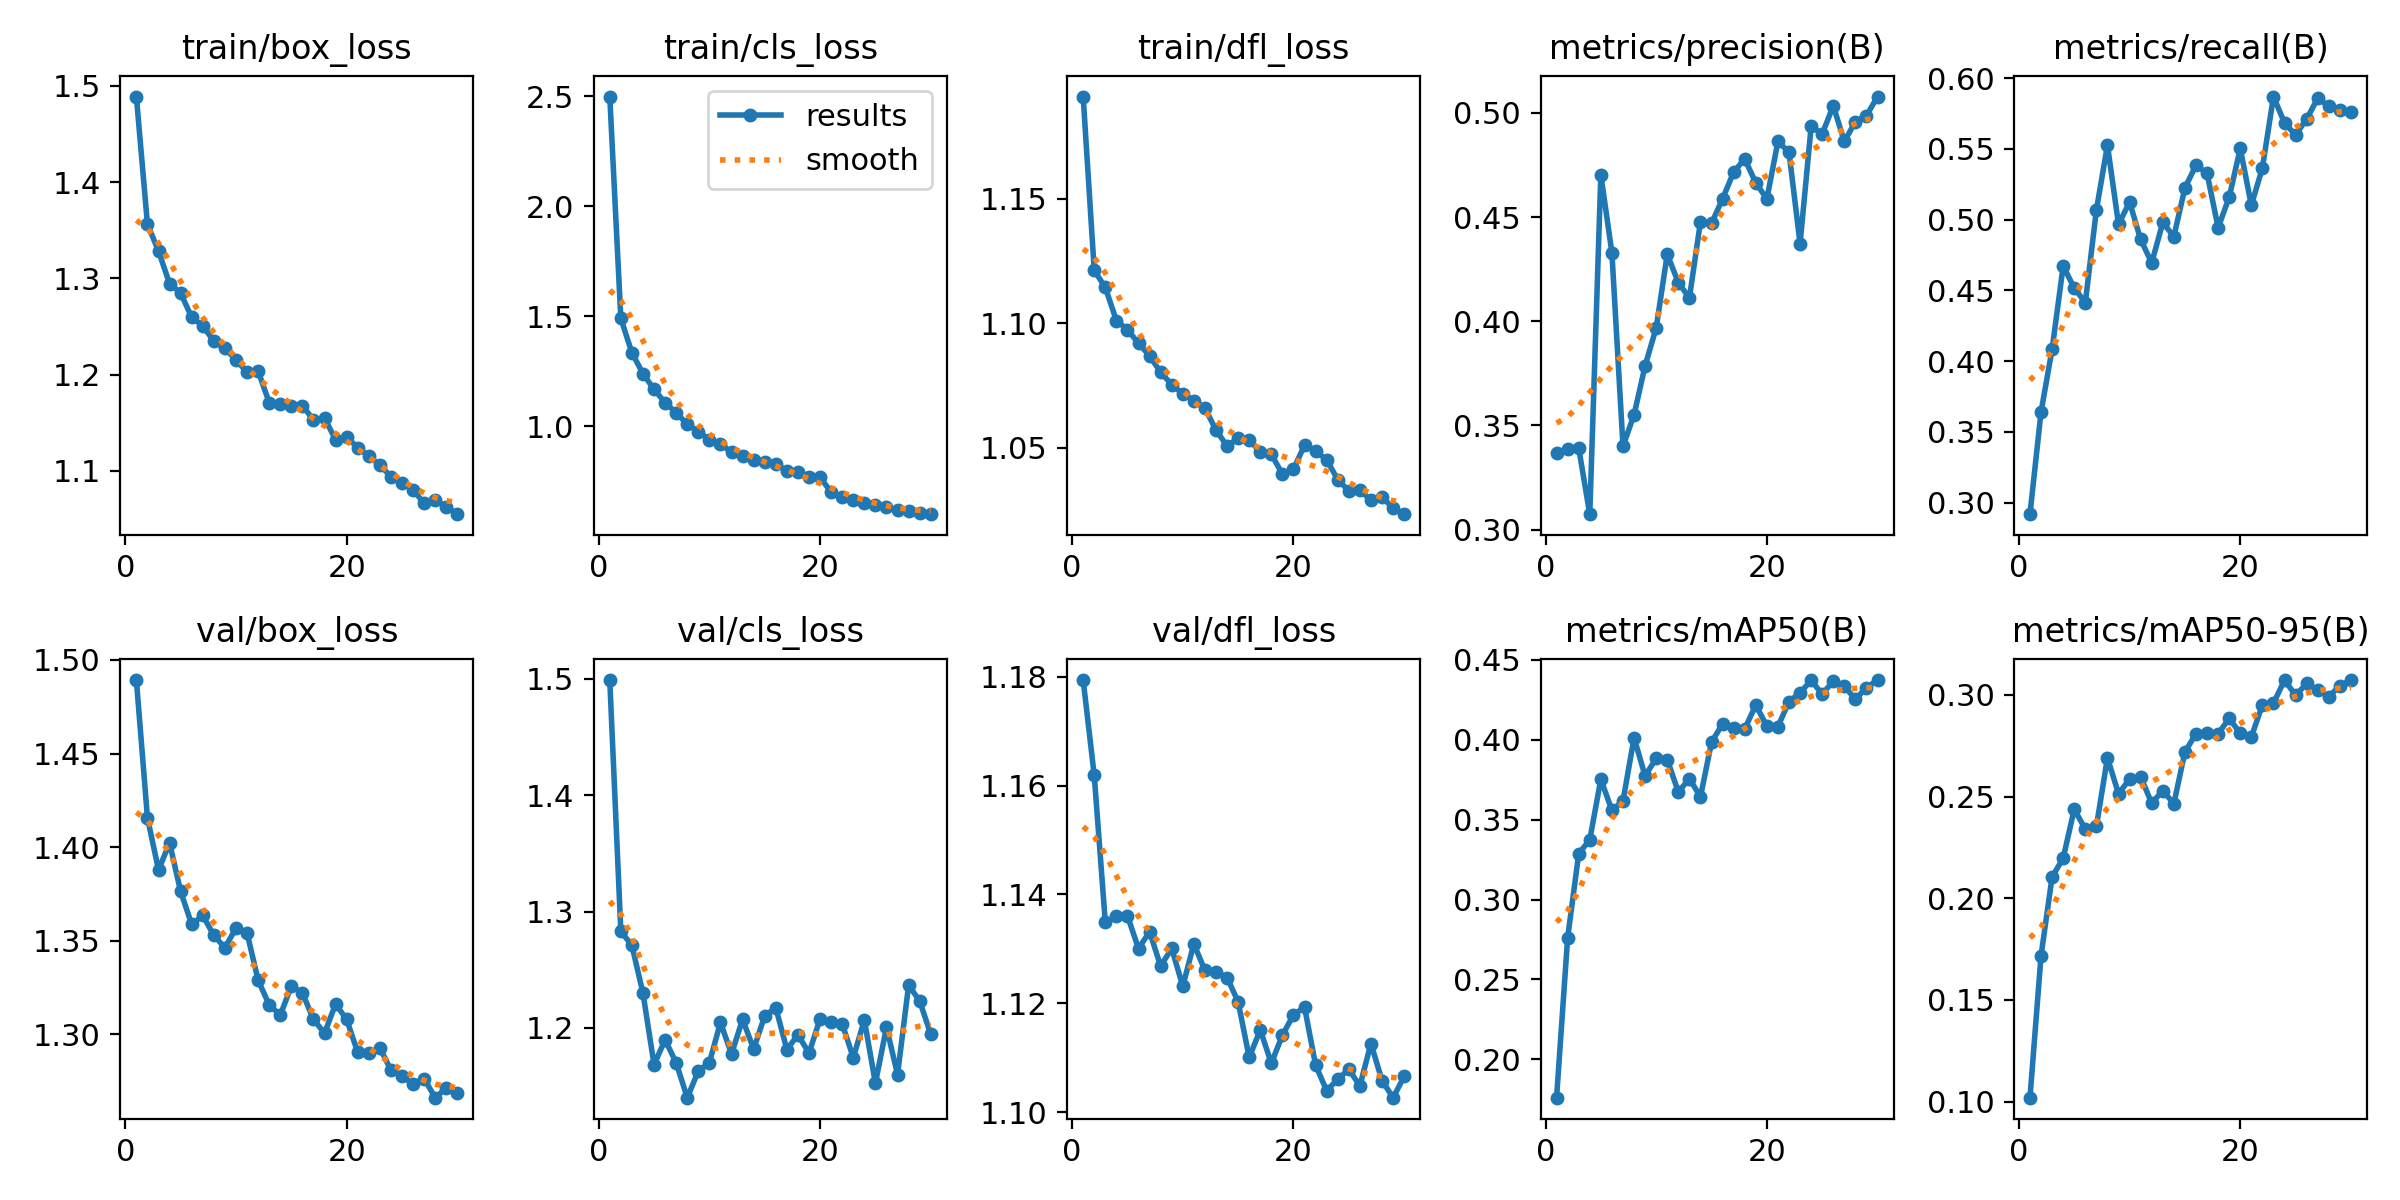

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View a screenshot of the training plots (Loss Function plots / Accuracy)
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

DisplayImage(filename=f'/{LATEST_TRAIN_DIR}/results.png', width=600)

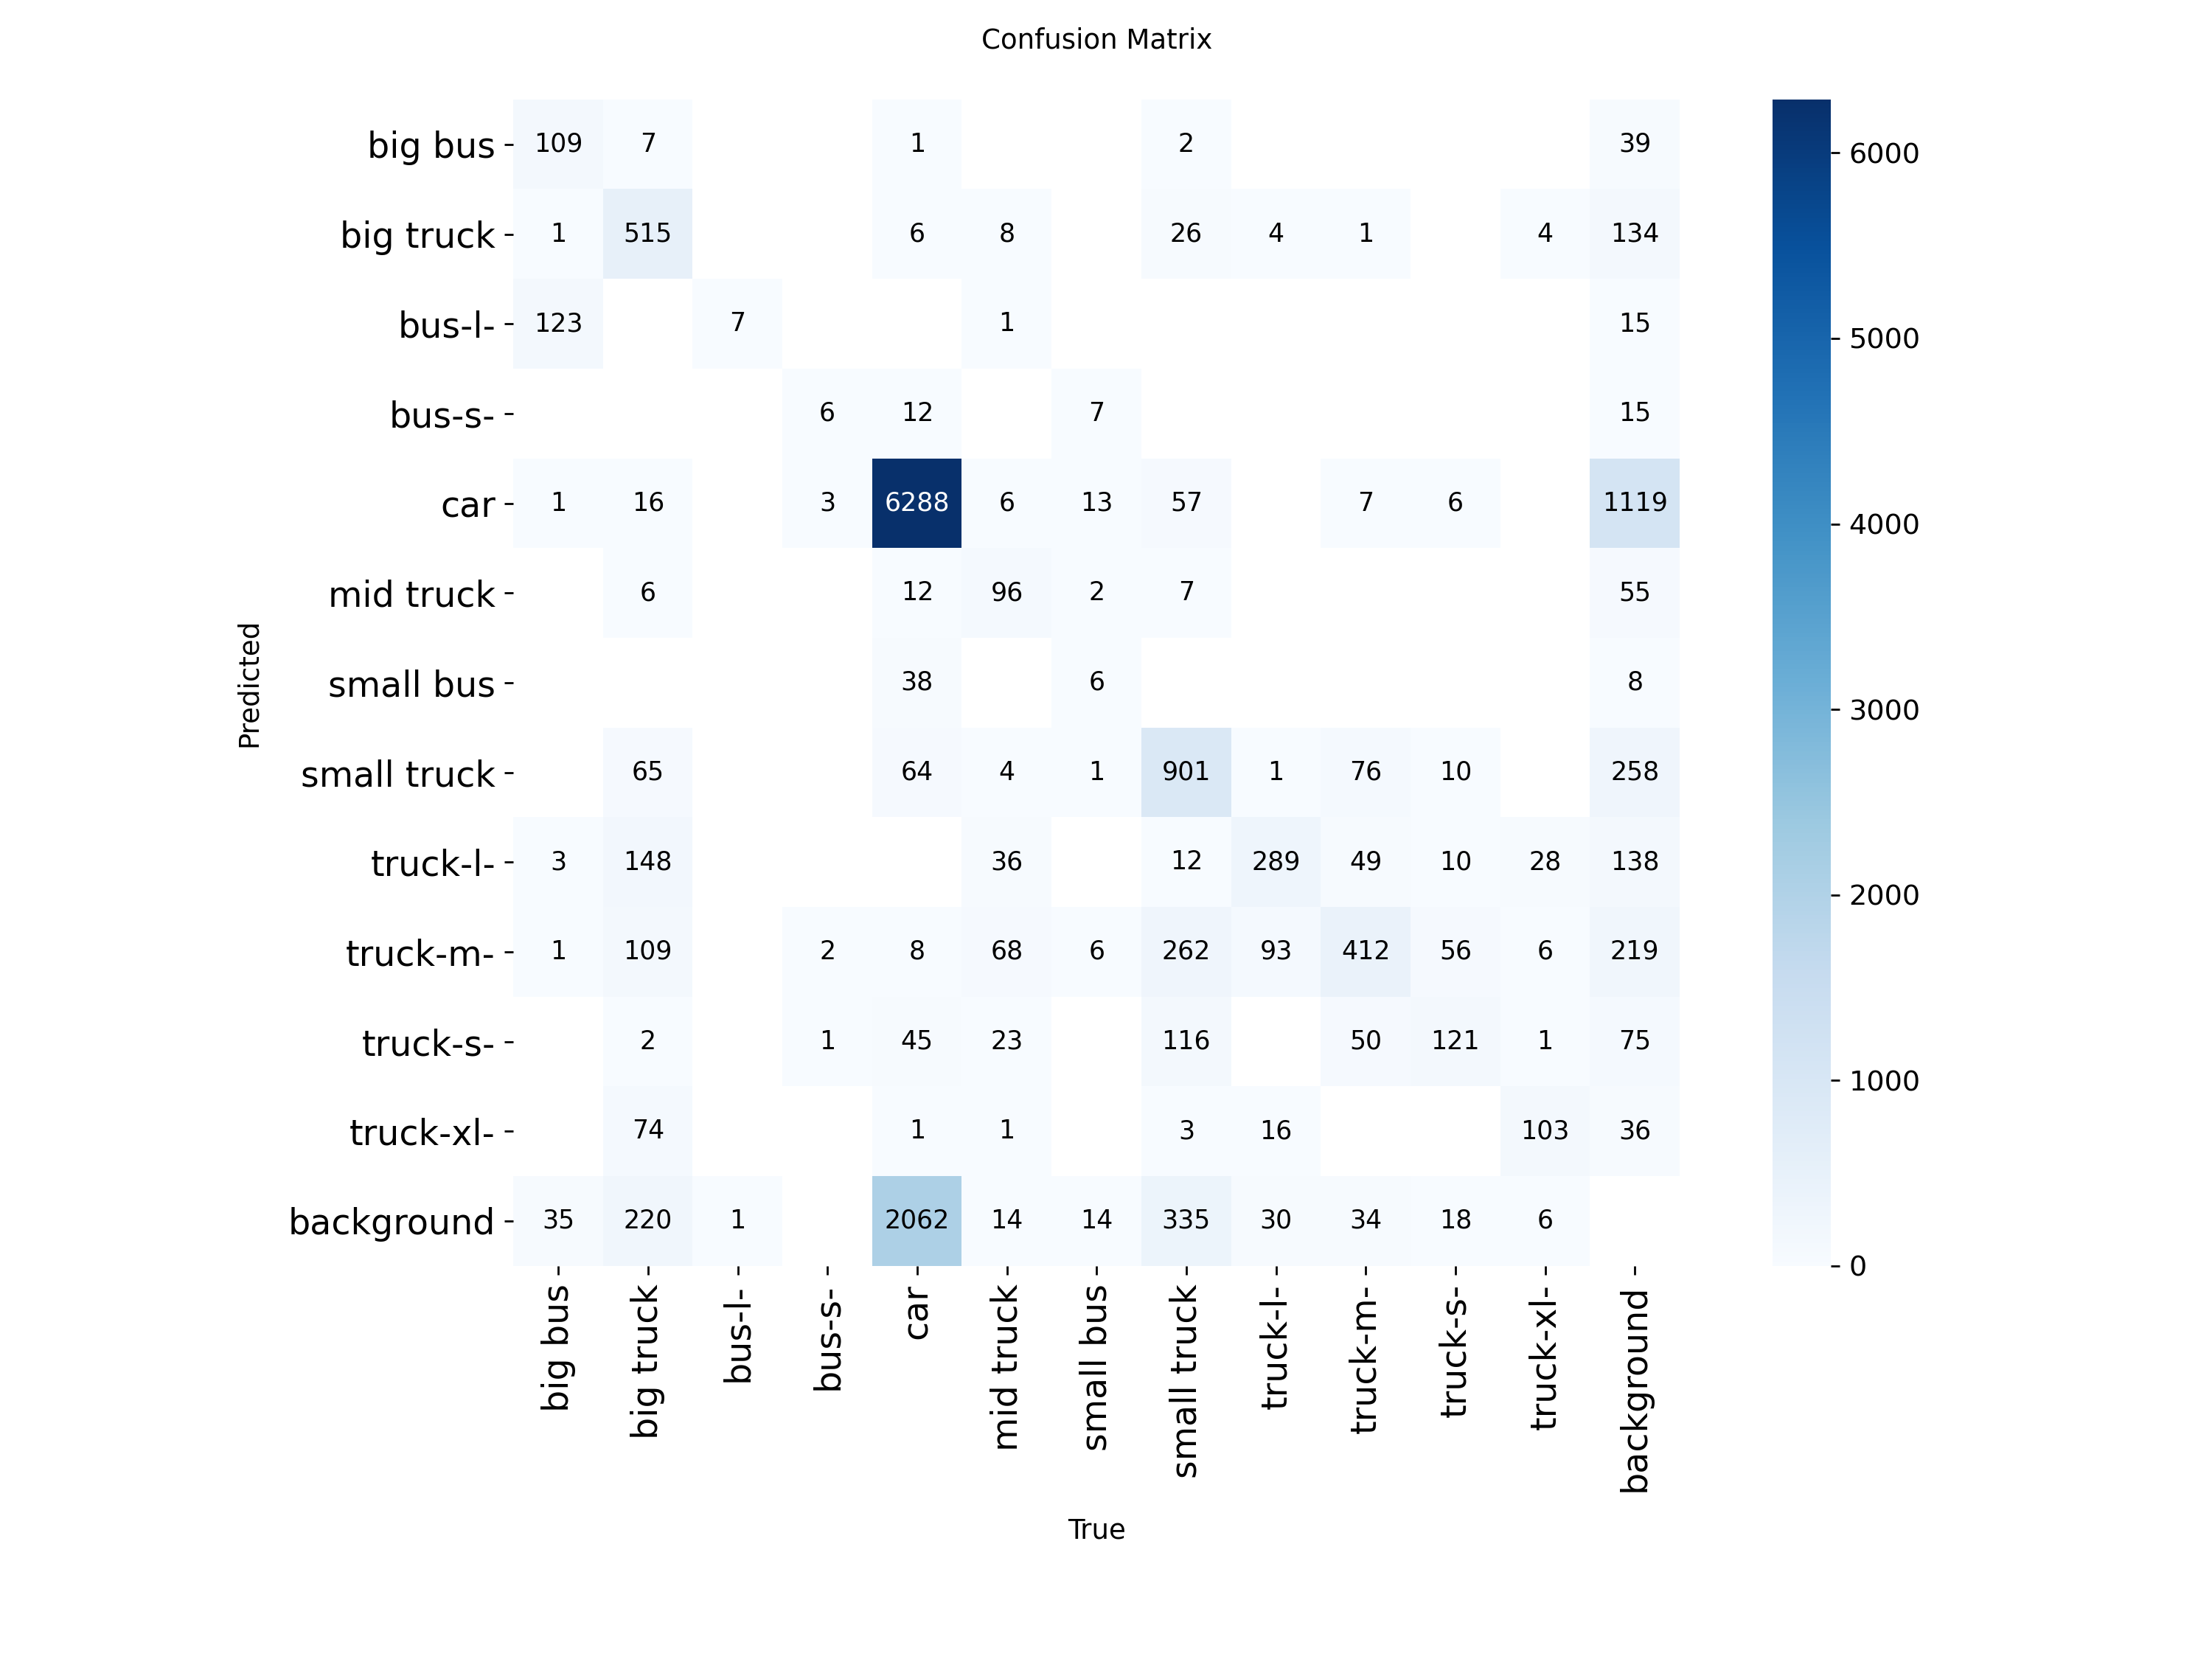

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View a screenshot of the Confusio Matrix
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

DisplayImage(filename=f'/{LATEST_TRAIN_DIR}/confusion_matrix.png', width=600)

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View training metrics
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# model.val(data=DATA_YAML_PATH) # dumps everything (verbose)

metrics = model.val(data=DATA_YAML_PATH)

print("mAP@0.5      :", metrics.box.map50)
print("mAP@0.5:0.95 :", metrics.box.map)
print("Precision    :", metrics.box.mp)
print("Recall       :", metrics.box.mr)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1955.5±760.0 MB/s, size: 54.4 KB)
val: Scanning /content/vehicles-1/valid/labels.cache... 966 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 966/966 368.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 5.2it/s 11.8s
                   all        966      13450      0.494      0.568      0.437      0.307
               big bus        210        273      0.781      0.419       0.68      0.497
             big truck        404       1162      0.845      0.435      0.643      0.413
                bus-l-          8          8     0.0499      0.875     0.0493     0.0269
                bus-s-         12         12      0.256       0.75      0.343       0.28
                   car        927       8537      0.874       0.69      0.823      0.509
             mid truck        118   

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Run inference on an arbitrary image and save it to the sandbox folder
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# I've provided a URL to an image, but you can just as easily upload a file into Colab contents folder
# and use that as your source

CONFIG_SAMPLE_IMAGE = "https://www.iii.org/sites/default/files/p_cars_highway_522785736.jpg"

#model.predict(source=f"/content/{SAMPLE_IMAGE}", save=True, conf=0.25)

model.predict(
    source = CONFIG_SAMPLE_IMAGE,
    save=True,
    conf=0.25,
    name=f"sandbox",
    exist_ok=True
)


Opening: /content/runs/detect/sandbox/p_cars_highway_522785736.jpg 



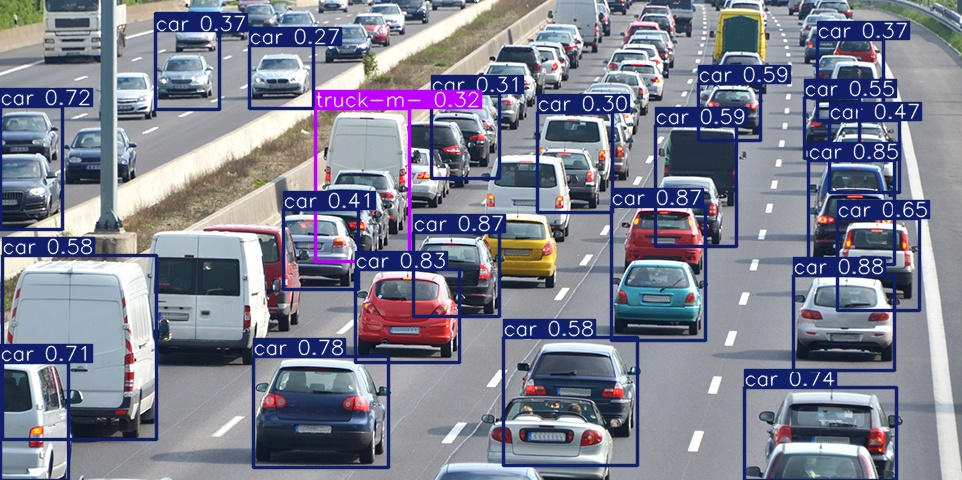

In [ ]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View a screenshot of the predicted annotated result
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# find the saved image (YOLO keeps original name or auto-generated one)
predicted_images = glob.glob(os.path.join("/content/runs/detect/sandbox", "*.jpg"))

# Sort by last modified time (oldest → newest)
predicted_images.sort(key=os.path.getmtime)
latest_image = predicted_images[-1]

print("Opening:", latest_image,"\n")

DisplayImage(
    filename=latest_image,
    width=600
)

In [ ]:
input_video = "/content/input.mp4"   # upload or mount from Drive
results = model.predict(source=input_video, save=True, conf=0.25)

In [ ]:
# Frame-by-frame video inference (LIMITED TO FIRST 200 FRAMES)

!pip -q install ultralytics opencv-python

import os
import cv2
#from ultralytics import YOLO
from IPython.display import HTML
from base64 import b64encode

# ---------------------------
# 1) Paths (EDIT THESE)
# ---------------------------
MODEL_PATH = MODEL_PT_PATH
INPUT_VIDEO = "/content/input.mp4"
OUTPUT_VIDEO = "/content/output_annotated_200frames.mp4"

MAX_FRAMES = 200   # ← LIMIT HERE
CONF_THRESH = 0.25

# ---------------------------
# 2) Load model
# ---------------------------
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found at: {MODEL_PATH}")

if not os.path.exists(INPUT_VIDEO):
    raise FileNotFoundError(f"Input video not found at: {INPUT_VIDEO}")

model = YOLO(MODEL_PATH)

# ---------------------------
# 3) Setup video reader/writer
# ---------------------------
cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise RuntimeError(f"Failed to open video: {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS)
if not fps or fps <= 0:
    fps = 30.0  # fallback

w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (w, h))

if not writer.isOpened():
    raise RuntimeError(f"Failed to open VideoWriter for: {OUTPUT_VIDEO}")

# ---------------------------
# 4) Inference loop (limited)
# ---------------------------
frame_idx = 0

while frame_idx < MAX_FRAMES:
    ret, frame_bgr = cap.read()
    if not ret:
        print("Reached end of video.")
        break

    results = model.predict(frame_bgr, conf=CONF_THRESH, verbose=False)
    annotated_frame = results[0].plot()

    writer.write(annotated_frame)

    frame_idx += 1

    if frame_idx % 25 == 0:
        print(f"Processed {frame_idx} frames...")

# ---------------------------
# 5) Cleanup
# ---------------------------
cap.release()
writer.release()

print(f"Done. Processed {frame_idx} frames.")
print("Saved to:", OUTPUT_VIDEO)

# ---------------------------
# 6) Display output
# ---------------------------
if os.path.exists(OUTPUT_VIDEO):
    mp4 = open(OUTPUT_VIDEO, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML(f"""
    <video width="900" controls>
      <source src="{data_url}" type="video/mp4">
    </video>
    """))
else:
    print("Output video not found.")

In [ ]:
# Option B: Frame-by-frame video inference in Google Colab (OpenCV + Ultralytics YOLO)
# - Reads an input video
# - Runs detection on every frame
# - Draws boxes/labels on frames
# - Writes an annotated output video
# - Displays the result inline in Colab

!pip -q install ultralytics opencv-python

import os
import cv2
#from ultralytics import YOLO
from IPython.display import HTML
from base64 import b64encode

# ---------------------------
# 1) Paths (EDIT THESE)
# ---------------------------
#MODEL_PATH = "/content/runs/detect/train/weights/best.pt"  # <-- your trained weights
INPUT_VIDEO = "/content/input.mp4"                          # <-- your video path
OUTPUT_VIDEO = "/content/output_annotated.mp4"


print("Exists:", os.path.exists(INPUT_VIDEO))
if os.path.exists(INPUT_VIDEO):
    print("Size (bytes):", os.path.getsize(INPUT_VIDEO))

!ls -lah /content | sed -n '1,200p'

# ---------------------------
# 2) Load model
# ---------------------------
if not os.path.exists(MODEL_PT_PATH):
    raise FileNotFoundError(f"Model not found at: {MODEL_PT_PATH}")
if not os.path.exists(INPUT_VIDEO):
    raise FileNotFoundError(f"Input video not found at: {INPUT_VIDEO}")

model = YOLO(MODEL_PT_PATH)

# ---------------------------
# 3) Video reader/writer setup
# ---------------------------
cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise RuntimeError(f"Failed to open video: {INPUT_VIDEO}")

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 0:
    fps = 30.0  # fallback if metadata is missing

w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# mp4v is typically safe in Colab for .mp4 output
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (w, h))
if not writer.isOpened():
    raise RuntimeError(f"Failed to open VideoWriter for: {OUTPUT_VIDEO}")

# ---------------------------
# 4) Inference loop
# ---------------------------
conf_thresh = 0.25  # adjust as needed
frame_idx = 0

while True:
    ret, frame_bgr = cap.read()
    if not ret:
        break

    # Ultralytics can take numpy arrays directly. It expects BGR or RGB? It handles numpy input fine.
    # We'll pass BGR frame; plotting will return an annotated BGR image.
    results = model.predict(frame_bgr, conf=conf_thresh, verbose=False)

    # results[0] corresponds to this frame
    annotated_bgr = results[0].plot()  # draws boxes/labels

    writer.write(annotated_bgr)

    frame_idx += 1
    if frame_idx % 50 == 0:
        print(f"Processed {frame_idx} frames...")

cap.release()
writer.release()

print("Done.")
print("Saved annotated video to:", OUTPUT_VIDEO)

# ---------------------------
# 5) Display output video inline
# ---------------------------
if os.path.exists(OUTPUT_VIDEO):
    mp4 = open(OUTPUT_VIDEO, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    HTML(f"""
    <video width="900" controls>
      <source src="{data_url}" type="video/mp4">
    </video>
    """)
else:
    print("Output video not found; something went wrong.")